In [2]:
# testing the kernel for scmpra package
import scMPRAforge as scm 

2025-12-12 14:21:27.768866: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-12 14:21:27.772452: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [3]:
import pandas as pd
import urllib.request
import subprocess 
import h5py
from scipy.sparse import csc_matrix
import scipy.sparse as sp
import scanpy as sc
from anndata import AnnData
#import scikit

In [4]:
data_root="/home/sxl6/project_pi_skr2/sxl6/tabula_data/seelig"
name="GSE269037_RAW"

In [5]:

seelig_data_path=f"{data_root}/{name}.tar"
#paper is here https://www.cell.com/cell-systems/fulltext/S2405-4712%2825%2900135-8
# the GEO dataset https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE269037
urllib.request.urlretrieve("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE269037&format=file",
                           seelig_data_path)

('/home/sxl6/project_pi_skr2/sxl6/tabula_data/seelig/GSE269037_RAW.tar',
 <http.client.HTTPMessage at 0x147ff2643010>)

In [6]:
subprocess.run(['tar', '-xf', seelig_data_path, '-C', f"{data_root}"], check=True)

CompletedProcess(args=['tar', '-xf', '/home/sxl6/project_pi_skr2/sxl6/tabula_data/seelig/GSE269037_RAW.tar', '-C', '/home/sxl6/project_pi_skr2/sxl6/tabula_data/seelig'], returncode=0)

extrated two files 
GSM8305416_R1-scMPRA.h5  GSM8305417_R1-scMPRA_tx.h5

In [7]:
file_1=h5py.File(f"{data_root}/GSM8305416_R1-scMPRA.h5",'r')
file_2=h5py.File(f"{data_root}/GSM8305417_R1-scMPRA_tx.h5")
group = list(file_1.keys())[0]
#print(group)
# repeat for file 2 
group = list(file_2.keys())[0]
print(group)


unknown


note: my file2 is the tx file 

In [8]:
print(list(file_1[list(file_1.keys())[0]]))
print(list(file_2[list(file_2.keys())[0]]))


['barcodes', 'data', 'gene_names', 'genes', 'indices', 'indptr', 'shape']
['barcodes', 'data', 'gene_names', 'genes', 'indices', 'indptr', 'shape']


In [9]:
def decode(handle):
    unknown_group = handle['unknown']
    
    # Load the sparse matrix components
    data = unknown_group['data'][:]
    indices = unknown_group['indices'][:]
    indptr = unknown_group['indptr'][:]
    shape = unknown_group['shape'][:]
    
    # Load barcodes and gene names
    barcodes = unknown_group['barcodes'][:].astype(str)
    genes = unknown_group['genes'][:].astype(str)
    genes = [gene.decode('utf-8') for gene in unknown_group['genes'][:]]
    gene_names = unknown_group['gene_names'][:].astype(str)

    sparse_matrix = csc_matrix((data, indices, indptr), shape=shape)

    # Determine which has fewer unique values for the outer index
    multi_index=None
    if len(set(genes)) < len(set(gene_names)):
        multi_index = pd.MultiIndex.from_tuples(list(zip(genes, gene_names)), names=['Gene', 'Gene Name'])
    else:
        multi_index = pd.MultiIndex.from_tuples(list(zip(gene_names, genes)), names=['Gene Name', 'Gene'])

    df= pd.DataFrame.sparse.from_spmatrix(sparse_matrix, index=multi_index, columns=barcodes)
    df.columns.name = 'Cell Barcode'
    return df

    
MPRA=decode(file_1)
GEX=decode(file_2)

In [10]:
flatty=MPRA.reset_index()
# gene name and gene are identical 
all(flatty["Gene Name"]==flatty["Gene"])

True

In [14]:
#save to csv file so i don't have to run previous cells again 
flatty.to_csv(f"{data_root}/seelig_mpra_unpro.tsv",sep="\t")

In [11]:
data=pd.read_csv(f"{data_root}/seelig_mpra_unpro.tsv",index_col=0,sep="\t")
# set the index of the rows to be gene 
data.index=data['Gene']
# delete the gene name and gene columns 
data.drop(['Gene Name','Gene'],axis=1,inplace=True)
data=data.stack().reset_index()
data.rename({'level_1': 'cell_bc',0:'umis_mpra_bc'},axis=1,inplace=True)
#print(data.head())
# turn umi counts into integers
data['umis_mpra_bc']=data['umis_mpra_bc'].astype(int)
dat = data
print(dat.head())


                                                Gene   cell_bc  umis_mpra_bc
0  AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...  A9_A2_A2             0
1  AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...  A6_A2_A2             0
2  AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...  A2_B1_A2             0
3  AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...  A5_B2_A2             0
4  AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...  A1_B2_A2             0


explore scanpy and AnnData

In [12]:
import h5py
import numpy as np
import pandas as pd
from scipy.sparse import csc_matrix
from anndata import AnnData

unknown = file_2['unknown']

# --- Read strings safely (avoid b'...') ---
barcodes   = unknown['barcodes'].asstr()[...]      # 1D array of cell barcodes
genes      = unknown['genes'].asstr()[...]         # 1D array of gene IDs
gene_names = unknown['gene_names'].asstr()[...]    # 1D array of gene symbols

# --- Read sparse components with correct dtypes ---
data   = unknown['data'][...].astype(np.float32)
indices = unknown['indices'][...].astype(np.int32)
indptr  = unknown['indptr'][...].astype(np.int32)

# shape needs to be a tuple of ints, not a numpy array
shape = tuple(unknown['shape'][...].astype(int))

# Build CSC as stored (typically genes x cells), then transpose to cells x genes for AnnData
X_csc = csc_matrix((data, indices, indptr), shape=shape)
X = X_csc.T.tocsr()   # AnnData expects n_obs (cells) x n_vars (genes)

# sanity check for annData structure 
assert X.shape[0] == len(barcodes), f"cells mismatch: X has {X.shape[0]} rows, barcodes has {len(barcodes)}"
assert X.shape[1] == len(genes),    f"genes mismatch: X has {X.shape[1]} cols, genes has {len(genes)}"

# Ensure unique indices (AnnData requires unique obs/var index)
obs_index = pd.Index(barcodes, name="barcode")
if not obs_index.is_unique:
    # if duplicates occur, make them unique deterministically
    obs_index = pd.Index(pd.io.parsers.ParserBase({'names':[]})._maybe_dedup_names(list(obs_index)), name="barcode")

var_index = pd.Index(genes, name="gene_id")
if not var_index.is_unique:
    # drop duplicates, keeping first occurrence (or choose a different policy)
    keep_mask = ~var_index.duplicated(keep="first")
    X = X[:, keep_mask]
    var_index = var_index[keep_mask]
    gene_names = gene_names[keep_mask]

# Build obs/var as DataFrames (not bare arrays)
obs_df = pd.DataFrame(index=obs_index)
var_df = pd.DataFrame(index=var_index)
var_df["gene_name"] = gene_names

tx_adata = AnnData(X=X, obs=obs_df, var=var_df)

# check AnnData content 

print(tx_adata)

#tx_adata.var

AnnData object with n_obs × n_vars = 10640 × 61225
    var: 'gene_name'


In [13]:
tx_adata.var

,gene_name
gene_id,
ENSG00000290825.1,DDX11L2
ENSG00000223972.6,DDX11L1
ENSG00000227232.5,WASH7P
ENSG00000278267.1,MIR6859-1
ENSG00000243485.5,MIR1302-2HG
...,...
ENSG00000198695.2,MT-ND6
ENSG00000210194.1,MT-TE
ENSG00000198727.2,MT-CYB


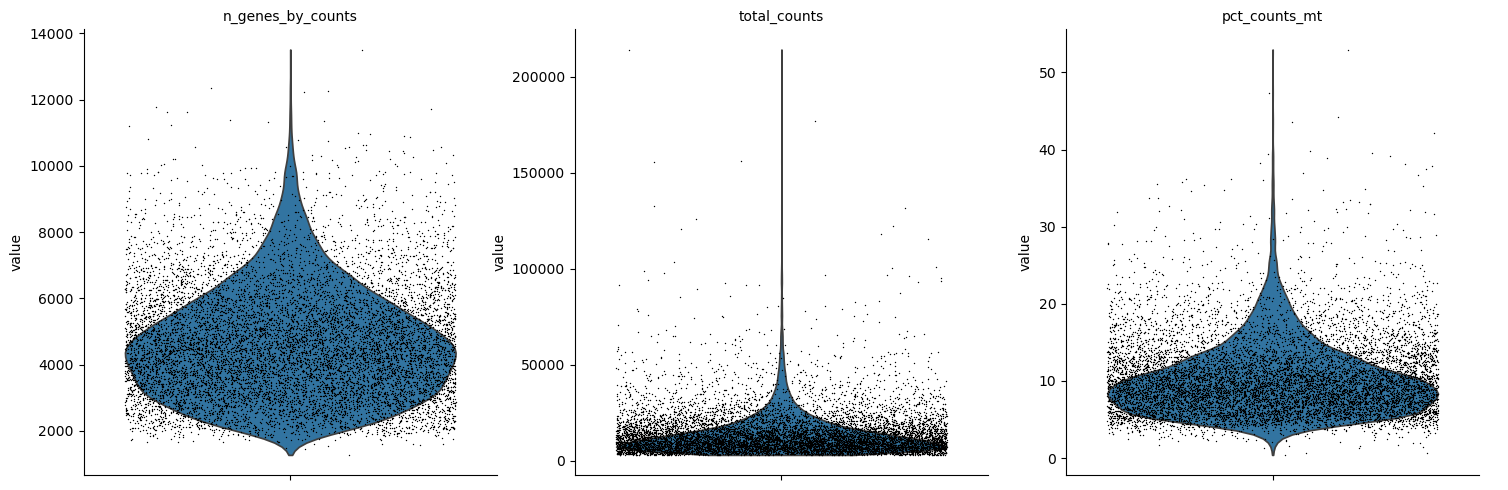

In [14]:
tx_adata.var["mt"] = tx_adata.var["gene_name"].str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    tx_adata,qc_vars=["mt"], inplace=True, log1p=True
)

sc.pl.violin(
    tx_adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

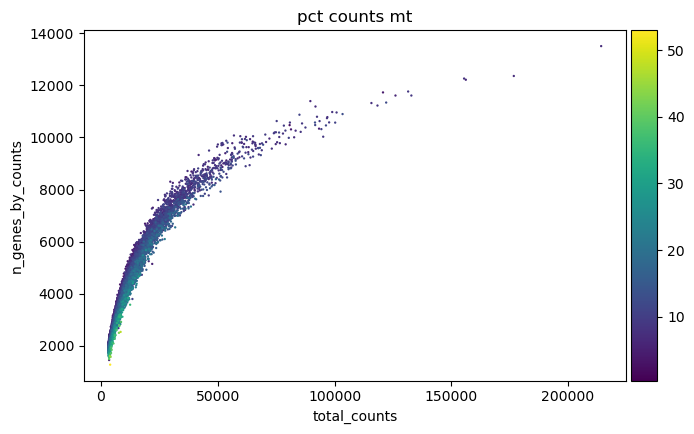

In [15]:
sc.pl.scatter(tx_adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [16]:
sc.pp.filter_cells(tx_adata, min_genes=100)
sc.pp.filter_genes(tx_adata, min_cells=3)

In [17]:
# kill doublets: takes a few minutes to run 
sc.pp.scrublet(tx_adata)

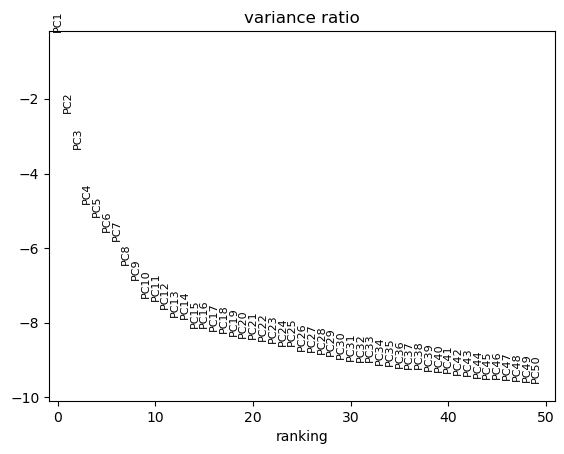

In [18]:
sc.tl.pca(tx_adata)
sc.pl.pca_variance_ratio(tx_adata, n_pcs=50, log=True)

In [19]:
tx_adata.layers["counts"] = tx_adata.X.copy()

In [20]:
# normalize the data ! 

sc.pp.normalize_total(tx_adata)
# Logarithmize the data
sc.pp.log1p(tx_adata)


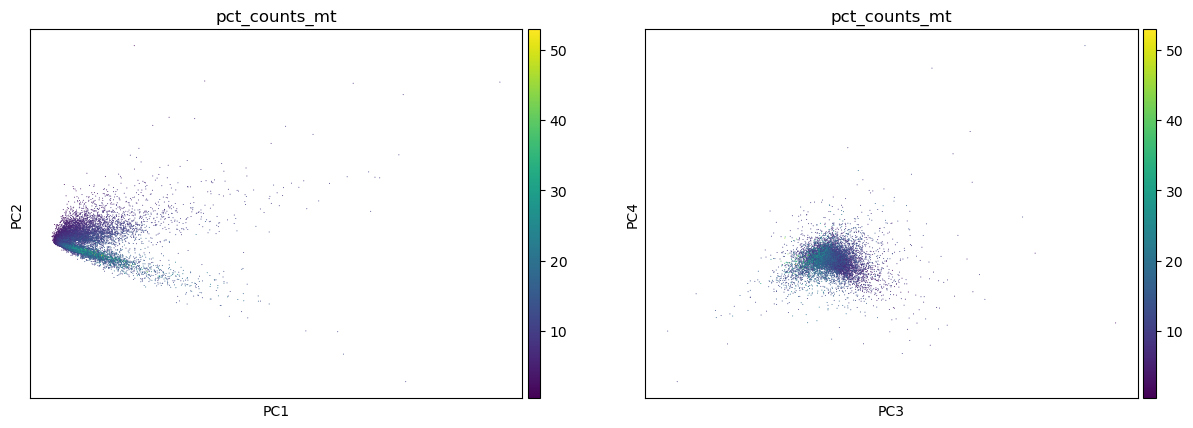

In [21]:
sc.pl.pca(
    tx_adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [22]:
sc.pp.neighbors(tx_adata)

In [23]:
sc.tl.umap(tx_adata)

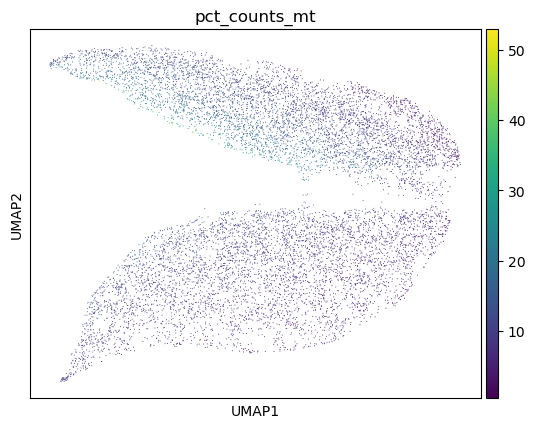

In [24]:
sc.pl.umap(
    tx_adata,
    color="pct_counts_mt",
    size=2,
)

In [25]:
sc.tl.leiden(tx_adata, flavor="igraph", n_iterations=2)

In [26]:
tx_adata.var.index=tx_adata.var["gene_name"]

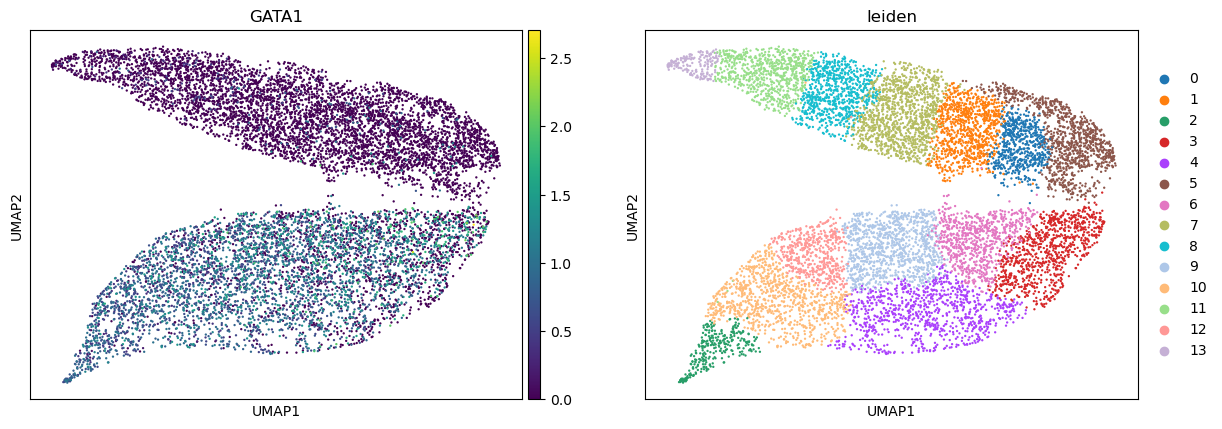

In [27]:
markers=["GATA1"]
sc.pl.umap(
    tx_adata,
    color=[*markers, "leiden"],
    ncols=3,
)

In [28]:
hepg2_clusters=["0","1","5","7","8","11","13"]
k562_clusters=["2","3", "4","6","9","10", "12"]

cluster_to_celltype={i:"K562" for i in k562_clusters} | {i:"HEPG2" for i in hepg2_clusters}

tx_adata.obs["cell_type"] = tx_adata.obs["leiden"].map(cluster_to_celltype)

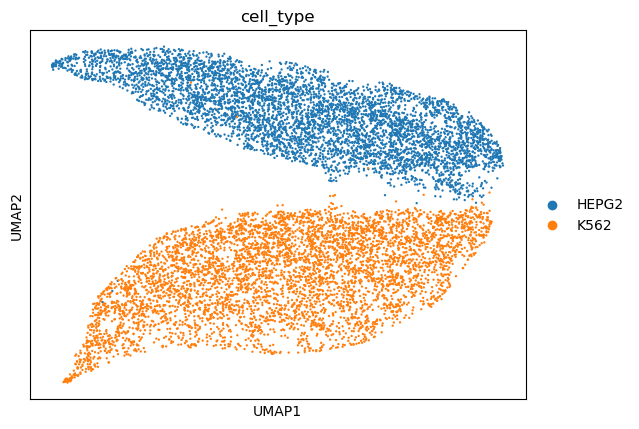

In [29]:
sc.pl.umap(
    tx_adata,
    color=["cell_type"],
)

In [30]:
tx_adata.write(f"{data_root}/filtered_seelig_tx.h5ad",compression="gzip")



In [31]:
tx_adata.obs[["cell_type"]].to_csv("/home/sxl6/project_pi_skr2/sxl6/acceptible_cells_and_cell_type.tsv",sep="\t")

In [32]:
acceptible_cells_and_cell_type=pd.read_csv("/home/sxl6/project_pi_skr2/sxl6/acceptible_cells_and_cell_type.tsv",sep="\t")

In [33]:
acceptible_cells_and_cell_type

,barcode,cell_type
0,A9_A2_A2,HEPG2
1,A6_A2_A2,K562
2,A2_B1_A2,HEPG2
3,A5_B2_A2,K562
4,A1_B2_A2,HEPG2
...,...,...
10635,A7_F6_F8,K562
10636,A12_F7_F8,HEPG2
10637,A5_F7_F8,K562
10638,A5_F8_F8,K562


In [34]:
acceptible_cells_and_cell_type.rename({'barcode':'cell_bc'},axis=1,inplace=True)

In [35]:
#make sure no dup cell barcodes : would cause duplicated data
assert len(acceptible_cells_and_cell_type["cell_bc"])==len(acceptible_cells_and_cell_type["cell_bc"].unique())

In [41]:
merged=dat.merge(acceptible_cells_and_cell_type,how="inner",on="cell_bc")
merged

,Gene,cell_bc,umis_mpra_bc,cell_type
0,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A9_A2_A2,0,HEPG2
1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A6_A2_A2,0,K562
2,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A2_B1_A2,0,HEPG2
3,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A5_B2_A2,0,K562
4,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A1_B2_A2,0,HEPG2
...,...,...,...,...
14310795,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A7_F6_F8,0,K562
14310796,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A12_F7_F8,0,HEPG2
14310797,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A5_F7_F8,0,K562
14310798,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A5_F8_F8,0,K562


In [ ]:
merged.rename({'Gene':'cre_id'},axis=1,inplace=True)
# added a column showing the replicate number 
merged['rep_id'] = 'rep1'
merged

,cre_id,cell_bc,umis_mpra_bc,cell_type,rep_id
0,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A9_A2_A2,0,HEPG2,rep1
1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A6_A2_A2,0,K562,rep1
2,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A2_B1_A2,0,HEPG2,rep1
3,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A5_B2_A2,0,K562,rep1
4,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,A1_B2_A2,0,HEPG2,rep1
...,...,...,...,...,...
14310795,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A7_F6_F8,0,K562,rep1
14310796,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A12_F7_F8,0,HEPG2,rep1
14310797,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A5_F7_F8,0,K562,rep1
14310798,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,A5_F8_F8,0,K562,rep1


In [43]:
merged=merged[['cell_bc','rep_id','cre_id','cell_type','umis_mpra_bc']].copy()
merged

,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc
0,A9_A2_A2,rep1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,HEPG2,0
1,A6_A2_A2,rep1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,K562,0
2,A2_B1_A2,rep1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,HEPG2,0
3,A5_B2_A2,rep1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,K562,0
4,A1_B2_A2,rep1,AAAATATCTCTGTAGGCAGATGCTTACAGCTGCTGCCGCAGACATA...,HEPG2,0
...,...,...,...,...,...
14310795,A7_F6_F8,rep1,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,K562,0
14310796,A12_F7_F8,rep1,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,HEPG2,0
14310797,A5_F7_F8,rep1,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,K562,0
14310798,A5_F8_F8,rep1,TTTTTTGTTTTGTTCAATGTTGAACATTCTACCGGGATCATTGTTT...,K562,0


In [46]:
# add the DNA sequence information 
dna=pd.read_csv(f"{data_root}/dna.tsv",sep="\t",index_col=0)